# Complementaria Semana 8: Cadenas de Markov en Python I

<h2 style="color: #ADD8E6;">Objetivos de aprendizaje</h2>

Al finalizar esta sesión, el estudiante será capaz de:

1. Construir una CMTC en `jmarkov` a partir de una matriz generadora $Q$.
2. Interpretar las probabilidades transitorias y de estado estable como distribuciones de probabilidad discretas.
3. Formular y responder preguntas típicas sobre distribuciones (PMF, valor esperado, varianza, probabilidades acumuladas).
4. Simular una CMTC correctamente en `SimPy` modelando procesos de llegada y servicio.
5. Comparar resultados analíticos con resultados de simulación.

<h2 style="color: #ADD8E6;">Introducción a jmarkov</h2>


En esta sección construiremos una cadena de Markov en tiempo continuo (CMTC) sencilla con 3 estados. La idea de este ejercicio es ilustrar, de manera compacta, los principales cálculos que podemos realizar con `jmarkov`, tanto estructurales como probabilísticos.

Consideremos una cadena con variable $X\left(t\right)$ y un espacio de estados $S_x = \{1,2,3\}$. Las transiciones entre estados están gobernadas por la siguiente matriz generadora:


$$
Q_{(i,j)} = \begin{pmatrix}
-3 & 2 & 1 \\
1 & -4 & 3 \\
2 & 1 & -3
\end{pmatrix}
$$


> **Recordemos que en una CMTC**
> - Las filas de $Q$ suman cero.
> - Los elementos fuera de la diagonal son no negativos.
> - La diagonal es negativa y representa la tasa de salida del estado.


In [1]:
import numpy as np
from jmarkov.ctmc import ctmc

# Definimos la matriz generadora
Q = np.array([
    [-3, 2, 1],
    [1, -4, 3],
    [2, 1, -3]
])

# Verificamos que las filas sumen cero
print("Suma por filas:", Q.sum(axis=1))

# Creamos la cadena de jmarkov continua
cadena = ctmc(Q)

Suma por filas: [0 0 0]


Podemos verificar propiedades importantes de la cadena.

In [120]:
print("Número de estados:", cadena.n_states)

print("¿Es irreducible?:", cadena.is_irreducible())

print("¿Es ergódica?:", cadena.is_ergodic())

Número de estados: 3
¿Es irreducible?: True
¿Es ergódica?: True



<h3 style="color: #ADD8E6;">Análisis transitorio</h3>

Podemos calcular la distribución en un instante $ t $ dado un estado inicial indicado con un vector de estados inciales $ \overrightarrow{\pi}(0) $, así

$$
\overrightarrow{\pi}(t) = \overrightarrow{\pi}(0)e^{Qt},
$$

Supongamos que la cadena inicia en el estado 0 (esto lo indicamos con un 1 en el estado correspondiente):

$$
\overrightarrow{\pi}(0) = (1, 0, 0)
$$

> **Punto clave:** $\vec{\pi}(t)$ es un **vector de probabilidades**. Cada entrada $\pi_i(t)$ es la probabilidad de que la cadena esté en el estado $i$ en el instante $t$. Juntas, forman una distribución de probabilidad discreta sobre el espacio de estados.

`jmarkov` recibe como parámetros `t` y `alpha` para encontrar el vector de probabilidades $\overrightarrow{\pi}(t)$. Estos son el tiempo total que se esta evaluando y el vector de estados iniciales respectivamente. 

In [2]:
pi_0 = np.array([1, 0, 0])
t = 2

p_t = cadena.transient_probabilities(t=t, alpha=pi_0)

print(f"Distribución en t={t}:")
print(p_t)

# Asi por ejemplo, la probabilidad de estar en el estado 1 dado que empezamos en el estado 0,
#  luego de que transcurran t = 2 uniades de tiempo es:
print(f"\nLa probabilidad de estar en el estado 1 en t=2 es {round(p_t[1], 3)}")

Distribución en t=2:
[0.34615261 0.26926285 0.38458454]

La probabilidad de estar en el estado 1 en t=2 es 0.269


<h3 style="color: #ADD8E6;">Probabilidades en estado estable</h3>

Si la cadena es ergódica, existe una distribución estacionaria $ \pi $ tal que:

$$
\overrightarrow{\pi}\mathbb{Q =}\overrightarrow{0},
$$

$$
\sum_{i \in S}^{}\pi_{i} = 1
$$

> **Interpretación:** En el largo plazo, **sin importar el estado inicial**, la probabilidad de encontrar el sistema en cada estado converge a $\vec{\pi}$. Similar al caso de probabilidades transitorias, $\vec{\pi}$ es un vector de probabilidades.

Podemos calcularla directamente:

In [3]:
pi = cadena.steady_state()

print("Distribución estacionaria:")
print(pi)

# Asi por ejemplo, la probabilidad de estar en el estado 1 en el largo plazo es:
print(f"\nLa probabilidad de estar en el estado 1 en el largo plazo es", round(pi[1], 3))

Distribución estacionaria:
[0.34615385 0.26923077 0.38461538]

La probabilidad de estar en el estado 1 en el largo plazo es 0.269


<h3 style="color: #ADD8E6;">Tiempo de primera pasada</h3>

El tiempo promedio de primera pasada (hitting time) $m_{i,j}$ desde un estado inicial $i$ hacia un estado objetivo $j$ puede calcularse al escribir $m_{i,j}$ como

$$
m_{i,j} = \frac{1}{r_{ij}}\ \left( 1 + \sum_{k \neq j}^{}{q_{ik}m_{k,j}} \right).
$$

Esta expresión permite encontrar el tiempo $m_{i,j}$ a partir de los otros tiempos $m_{k,j}$, siendo $1/r_{i} = - 1/q_{ii}$. Matemáticamente, para encontrar $m_{i,j}$ hay que solucionar el sistema de ecuaciones simultaneas asociado. `jmarkov` ya implementa una función para encontrar los tiempos de primera pasada a un estado objetivo.

Por ejemplo, el tiempo promedio para llegar al estado 2 comenzando desde el estado 1 se calcula de la siguiente forma:

In [9]:
# Se define un array con los nombres de los estados
estados = ['0', '1', '2']
estados = np.array(estados)

estado_inicial = np.where(estados == '1')
estado_futuro = np.where(estados == '2')

# Calcular el tiempo
fpts = cadena.first_passage_time(estado_futuro)
# No tiene sentido calcular el tiempo de primera pasada al estado 2 desde el estado 2.
# Por lo tanto, el arreglo que se regresa es de n-1 estados.
print("Arreglo de tiempos de primera pasada al estado 2:")
print(fpts)


# La variable estado_inicial contiene el índice del estado '1', que es el estado desde el cual 
# queremos calcular el tiempo de primera pasada al estado '2'.
print(f"\nÍndice del estado inicial:", estado_inicial)

# Indexamos el tiempo de primera pasada desde el estado '1' al estado '2' utilizando el índice obtenido
# utilizamos [0][0] para obtener el numero directamente del array
tiempo_1_2 = fpts[estado_inicial][0][0]
print(f"\nEl tiempo de primera pasada desde el estado 1 al estado 2 es:", round(tiempo_1_2, 3))

Arreglo de tiempos de primera pasada al estado 2:
[[0.6]
 [0.4]]

Índice del estado inicial: (array([1]),)

El tiempo de primera pasada desde el estado 1 al estado 2 es: 0.4


<h3 style="color: #ADD8E6;">Tiempo de ocupación</h3>

En una cadena de Markov en tiempo continuo, el **tiempo de ocupación** mide cuánto tiempo, en promedio, el proceso pasa en cada estado durante un intervalo finito $[0,t]$, y se calcula como

$$
\mathbf{M}^{t} = \int_{0}^{t}{e^{\mathbf{Q}u}du}
$$

En la matriz resultante:

- Cada fila corresponde al estado inicial.
- Cada columna corresponde al estado donde se acumula el tiempo.

Por lo tanto para nuestro ejemplo, la matriz devuelta por `occupation_time(T)` tiene la forma:

$$
\mathbf{M}^{t} =
\begin{pmatrix}
\text{Tiempo desde 0 en 0} & \text{Tiempo desde 0 en 1} & \text{Tiempo desde 0 en 2} \\
\text{Tiempo desde 1 en 0} & \text{Tiempo desde 1 en 1} & \text{Tiempo desde 1 en 2} \\
\text{Tiempo desde 2 en 0} & \text{Tiempo desde 2 en 1} & \text{Tiempo desde 2 en 2}
\end{pmatrix}
$$

In [10]:

tiempo_ocupacion = cadena.occupation_time(T=4)

print("Tiempo esperado en cada estado en 4 unidades de tiempo:")
print(tiempo_ocupacion)

sum_tiempo_ocupacion = tiempo_ocupacion.sum(axis=1)
print(f"\nSuma del tiempo de ocupación por filas:", sum_tiempo_ocupacion)

print(f"\nTiempo en 2 desde 1:", round(tiempo_ocupacion[1][2], 3))

Tiempo esperado en cada estado en 4 unidades de tiempo:
[[1.52070832 1.0502945  1.42899215]
 [1.28993909 1.20414066 1.50591523]
 [1.32840063 1.01183297 1.65976138]]

Suma del tiempo de ocupación por filas: [3.99999497 3.99999497 3.99999497]

Tiempo en 2 desde 1: 1.506


<h3 style="color: #ADD8E6;">¿Qué preguntas puedo hacerle a una distribución?</h3>


Una vez que tenemos una distribución de probabilidad discreta (sea transitoria o en estado estable) podemos calcular cualquier medida típica de probabilidad y estadística:

| Pregunta | Fórmula | Código |
|----------|---------|--------|
| ¿Cuál es la prob. de estar en un estado específico? | $P(X = k) = \pi_k$ | `pi[k]` |
| ¿Cuál es la prob. de estar en un conjunto de estados? | $P(X \in A) = \sum_{k \in A} \pi_k$ | `pi[list_A].sum()` |
| ¿Cuál es el valor esperado? | $E[X] = \sum_k k \cdot \pi_k$ | `sum(k * pi[k] for k in S)` |
| ¿Cuál es la varianza? | $\text{Var}(X) = E[X^2] - (E[X])^2$ | `E[X**2] - E[X]**2` |
| ¿Cuál es el valor esperado de una función $g(X)$? | $E[g(X)] = \sum_k g(k) \cdot \pi_k$ | `sum(g(k)*pi[k] for k in S)` |


Ahora que vimos cómo utilizar las funciones básicas de `jmarkov` en cadenas continuas y algunas de las preguntas que podemos realizar con distribuciones discretas, sigamos con un ejercicio más elaborado (este ejercicio continuará en la siguiente complementaria **Cadenas de Markov en Python II**). 

<h2 style="color: #ADD8E6;">Ejercicio de implementación: Hospital en tiempo continuo</h2>

Considere un hospital con $B = 20$ camas. Hay dos tipos de pacientes que usan este hospital. Los pacientes de tipo $i\ (i=1,2)$ llegan según un proceso de Poisson con tasa $\lambda_1 = 6.5$ y $\lambda_2 = 3$ pacientes por hora, respectivamente, y requieren un servicio independiente e idénticamente distribuido (iid) con tiempos de servicio que siguen una distribución exponencial con parámetros $\mu_1 = 2$ y $\mu_2 = 1.5$ pacientes por hora, respectivamente. El hospital utiliza la siguiente política: reserva $b = 5$ camas para pacientes de tipo 1. Así, cuando un paciente de tipo 1 llega, se le admite en el hospital siempre que haya una cama disponible. Sin embargo, un paciente de tipo 2 es admitido solo si el número de pacientes de tipo 2 que actualmente ocupan camas es menor que $B-b$.

Se le ha solicitado modelar la anterior situación definiendo claramente variables de estado, espacios de estado y matriz de transición o generadora según sea el caso.


<h3 style="color: #ADD8E6;">Preguntas</h3>

1. Construya la matriz de tasas de transición $\mathbb{Q}$, luego cree la cadena de Markov utilizando la librería `jmarkov`.

Para responder las preguntas 2 a 5 asuma que el hospital inició vacío y transcurrieron 6 horas:

2. Calcule la probabilidad de que el hospital tenga 1 paciente tipo 1 y 3 pacientes tipo 2. Utilice `jmarkov` para responder.
3. Muestre la distribución conjunta del número de pacientes tipo 1 y tipo 2 en un mapa de calor.
4. Calcule las distribuciones marginales de los pacientes de ambos tipos, así como su valor esperado, varianza y desviación estándar. Realice un histograma que muestre las dos distribuciones.   
5. Responda nuevamente la pregunta 2 utilizando simulación en SimPy y compare los resultados.

<h4 style="color: #ADD8E6;">1. Construir la matriz de de transición y la cadena en jmarkov</h4>

**Variables de estado:**
- $X\left(t\right)$: El número de pacientes tipo 1 en el tiempo $t$.
- $Y\left(t\right)$: El número de pacientes tipo 2 en el tiempo $t$.
- $Z\left(t\right)$: $\{X\left(t\right),\ Y\left(t\right)\}$.

**Espacio de estados:**

$$
S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}
$$

$$
S_Y=\{0,\ 1,\ 2,\ 3,\ \ldots,B-b\}
$$

$$
S_Z=\{(i,j):0\le i\le B,\ 0\le j\le B-b\}
$$

>  **Nota:** El espacio de estados tiene $(B+1) \times (B-b+1) = 21 \times 16 = 336$ estados. La variable de estado $Z(t) = (X(t), Y(t))$ es **bidimensional**, lo cual hace que la distribución de probabilidad sea una distribución **conjunta** sobre dos variables.


**Matriz generadora:**

$$
Q((i,j),(i',j')) = \begin{cases}
\lambda_1, & \text{si } i' = i + 1,\; j' = j,\; i < B, \\[1mm]
\lambda_2, & \text{si } j' = j + 1,\; i' = i,\; j < B - b, \\[1mm]
i \cdot \mu_1, & \text{si } i' = i - 1,\; j' = j,\; i > 0, \\[1mm]
j \cdot \mu_2, & \text{si } j' = j - 1,\; i' = i,\; j > 0, \\[1mm]
0, & \text{en otro caso (d.l.c.)}.
\end{cases}
$$

> **¿Por qué la tasa de salida depende del número de pacientes?** Porque cada paciente se va de forma independiente con tasa $\mu_i$. Si hay $i$ pacientes tipo 1, cada uno intenta irse con tasa $\mu_1$, y por la propiedad de suma de exponenciales independientes, la tasa total de salida de un paciente tipo 1 es $i \cdot \mu_1$.




A continuación, se implementa el modelo en Python.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# Se definen los parámetros
B = 20  # Número total de camas
b = 5   # Número de camas reservadas para pacientes tipo 1
lambda_1 = 6.5  # Tasa de llegada de pacientes tipo 1 (por hora)
lambda_2 = 3  # Tasa de llegada de pacientes tipo 2 (por hora)
mu_1 = 2      # Tasa de salida de pacientes tipo 1 (por hora)
mu_2 = 1.5    # Tasa de salida de pacientes tipo 2 (por hora)

# Dimensión de la matriz Q
num_estados = (B + 1) * (B - b + 1)

# Inicializamos la matriz Q con ceros
Q_hospital = np.zeros((num_estados, num_estados), dtype=float)

# Función para mapear (i, j) a índice en la matriz Q
def index(i, j):
    return i * (B - b + 1) + j

# Llenar la matriz Q
for i in range(B + 1):
    for j in range(B - b + 1):
        idx = index(i, j)

        # Llegada de un paciente tipo 1
        if i < B:
            Q_hospital[idx, index(i + 1, j)] = lambda_1

        # Llegada de un paciente tipo 2 (si hay espacio disponible)
        if j < B - b:
            Q_hospital[idx, index(i, j + 1)] = lambda_2

        # Salida de un paciente tipo 1
        if i > 0:
            Q_hospital[idx, index(i - 1, j)] = i * mu_1

        # Salida de un paciente tipo 2
        if j > 0:
            Q_hospital[idx, index(i, j - 1)] = j * mu_2

# Llenar la diagonal con la suma negativa de las filas de la matriz
for i in range(num_estados):
    Q_hospital[i, i] = -np.sum(Q_hospital[i, :])


# Verificación
print("Suma por filas (debe ser ≈ 0):", np.allclose(Q_hospital.sum(axis=1), 0))
print(f"Tamaño de Q: {Q_hospital.shape}")    
print(Q_hospital)


Suma por filas (debe ser ≈ 0): True
Tamaño de Q: (336, 336)
[[ -9.5   3.    0.  ...   0.    0.    0. ]
 [  1.5 -11.    3.  ...   0.    0.    0. ]
 [  0.    3.  -12.5 ...   0.    0.    0. ]
 ...
 [  0.    0.    0.  ... -62.5   3.    0. ]
 [  0.    0.    0.  ...  21.  -64.    3. ]
 [  0.    0.    0.  ...   0.   22.5 -62.5]]


Es posible visualizar la matriz en excel

In [12]:
import pandas as pd

# Crear etiquetas para cada estado en formato "(i, j)"
etiquetas_estados = [f"({i},{j})" for i in range(B + 1) for j in range(B - b + 1)]

# Convertir la matriz de NumPy a un DataFrame de Pandas
df_Q = pd.DataFrame(Q_hospital, index=etiquetas_estados, columns=etiquetas_estados)

# 3. Exportar a Excel
nombre_archivo = "matriz_Q_hospital.xlsx"
df_Q.to_excel(nombre_archivo)

print(f"Matriz exportada exitosamente a {nombre_archivo}")

Matriz exportada exitosamente a matriz_Q_hospital.xlsx


Para crear la cadena de markov utilizaremos la instancia `ctmc` la libreria `jmarkov`, ya que estamos creando una cadena de tiempo continuo.

In [13]:
from jmarkov.ctmc import ctmc

# Crear la cadena de Markov en tiempo continuo usando jmarkov
hospital_chain = ctmc(Q_hospital)

print(f"Número de estados: {hospital_chain.n_states}")
print(f"¿Es irreducible?: {hospital_chain.is_irreducible()}")
print(f"¿Es ergódica?: {hospital_chain.is_ergodic()}")

Número de estados: 336
¿Es irreducible?: True
¿Es ergódica?: True


<h4 style="color: #ADD8E6;">2. Cálculo de la probabilidad: después de 6 horas, el hospital tenga 1 paciente tipo 1 y 3 pacientes tipo 2</h4>

La matriz exponencial $e^{Qt}$ corresponde a la matriz de probabilidades transitorias al tiempo $t$. En esta matriz, las filas representan el estado inicial y las columnas el estado al que se transita. La distribución de probabilidad en el tiempo $t$ está dada por:

$$
\pi(t) = \pi(0)e^{Qt}.
$$

Si se conoce con certeza el estado inicial, el vector $\pi(0)$ tiene un 1 en dicho estado y 0 en los demás. En general, si existe incertidumbre inicial, sus componentes deben ser no negativos y sumar 1.

En nuestro problema se parte del estado $(0,0)$, es decir,

$$
\begin{split}
\pi(0)=\begin{cases}
1, & i=0,\ j=0,\\
0, & \text{d.l.c.}
\end{cases}
\end{split}
$$

La probabilidad solicitada es el componente correspondiente al estado $(1,3)$ del vector $\pi(6)$:

$$
\big[\pi(0)e^{Q(6)}\big]_{(1,3)}
$$

Recordemos que el proceso conjunto es $Z(t) = (X(t),Y(t))$, por lo que el estado $(1,3)$ indica 1 paciente tipo 1 y 3 pacientes tipo 2.

> **Nota:** Dado que el estado inicial está completamente determinado, la multiplicación $\pi(0)e^{Q(6)}$ equivale a seleccionar la fila de $e^{Q(6)}$ correspondiente al estado $(0,0)$. Por lo tanto,
>
> $$
> \big[\pi(0)e^{Q(6)}\big]_{(1,3)}
> =
> \big[e^{Q(6)}\big]_{((0,0),(1,3))}
> $$

<h5 style="color: #ADD8E6;">Solución en jmarkov</h5>

Para resolver a esta pregunta primero se debe establecer correctamente el vector de estado inicial (hospital vacío).

In [14]:
# --------------------------------------------------------------------
# Pregunta 2: Probabilidad de que después de 6 horas el hospital tenga 1 paciente tipo 1, y 3
# pacientes tipo 2, dado que al inicio está vacío.
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1

Una vez definido este vector, se puede calcular la distribución de probabilidad a las 6 horas utilizando la función `transient_probabilities` de `jmarkov`

In [15]:
# Probabilidades transitorias en 6 horas
t_eval = 6
probs_transitorias_6h = hospital_chain.transient_probabilities(t=t_eval, alpha=alpha)

Con esto podemos identificar que la probabilidad correspondiente al estado $(1,3)$ es la siguiente:

In [16]:
# Probabilidad de que el estado sea (1,3)
prob_1_3 = probs_transitorias_6h[index(1, 3)]
print(f"P(X(6)=1, Y(6)=3) = {prob_1_3:.6f}")

P(X(6)=1, Y(6)=3) = 0.022737


<h4 style="color: #ADD8E6;">3. Visualización de la distribución conjunta después de 6 horas dado que el sistema inició vacío</h4>

Dado que el vector calculado en el punto anterior `probs_transitorias_6h` contiene las probabilidades de todas las posibles combinaciones de pacientes de tipo 1 y 2, dado que el hospital estaba vacío al inicio y de que transcurran 6 horas, es posible hacer un mapa de calor que ilustre el posible comportamiento del hospital según el tipo de paciente. 

In [17]:
# Reorganizar el vector en una matriz 2D para visualización
pi_matrix = np.zeros((B + 1, B - b + 1))
for i in range(B + 1):
    for j in range(B - b + 1):
        pi_matrix[i, j] = probs_transitorias_6h[index(i, j)]

print(f"Suma total de probabilidades: {pi_matrix.sum():.6f}")
print(f"Dimensión de la distribución conjunta: {pi_matrix.shape} (tipo1 × tipo2)")

Suma total de probabilidades: 1.000000
Dimensión de la distribución conjunta: (21, 16) (tipo1 × tipo2)


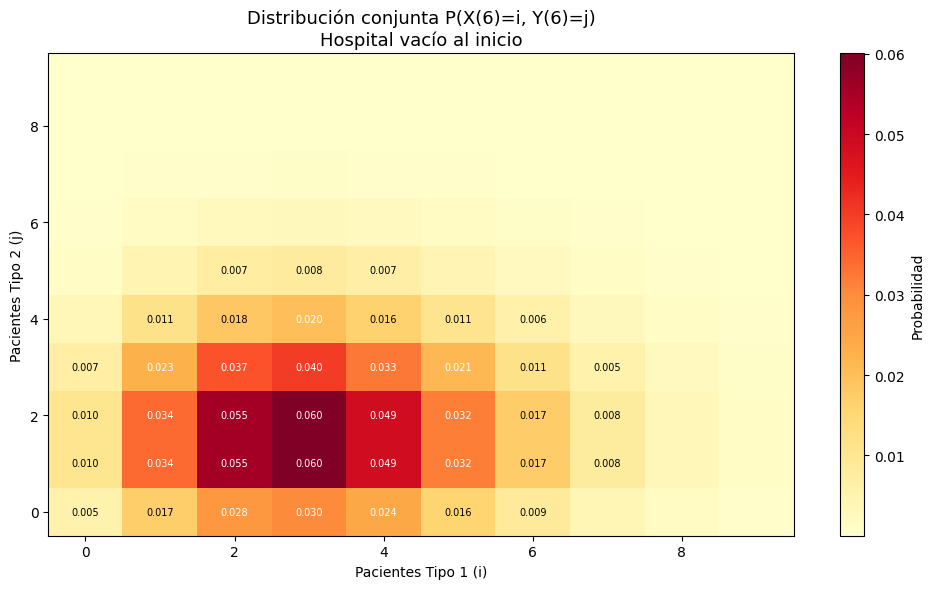

Estado más probable: (3, 1) con P = 0.0601


In [18]:
# Visualización: Heatmap de la distribución conjunta
fig, ax = plt.subplots(figsize=(10, 6))

# Solo mostramos la región con probabilidad significativa
max_i_show = 10   # Mostrar hasta 12 pacientes tipo 1
max_j_show = 10   # Mostrar hasta 12 pacientes tipo 2

region = pi_matrix[:max_i_show, :max_j_show]
im = ax.imshow(region.T, origin='lower', aspect='auto', cmap='YlOrRd')

ax.set_xlabel('Pacientes Tipo 1 (i)')
ax.set_ylabel('Pacientes Tipo 2 (j)')
ax.set_title(f'Distribución conjunta P(X({t_eval})=i, Y({t_eval})=j)\n'
             f'Hospital vacío al inicio', fontsize=13)

plt.colorbar(im, ax=ax, label='Probabilidad')

# Anotar las celdas con mayor probabilidad
for i in range(min(10, max_i_show)):
    for j in range(min(10, max_j_show)):
        val = region[i, j]
        if val > 0.005:
            ax.text(i, j, f'{val:.3f}', ha='center', va='center', fontsize=7,
                   color='white' if val > 0.02 else 'black')

plt.tight_layout()
plt.show()

print(f"Estado más probable: ", end="")
i_max, j_max = np.unravel_index(pi_matrix.argmax(), pi_matrix.shape)
print(f"({i_max}, {j_max}) con P = {pi_matrix[i_max, j_max]:.4f}")


<h4 style="color: #ADD8E6;">4. Probabilidades marginales de pacientes tipo 1 y 2</h4>

Un resultado interesante del mapa de calor es ver como el comportamiento de los pacientes tipo 1 y 2 está concentrado en un área y a medida que nos alejamos de esta, la probabilidad disminuye drásticamente.
Otra forma de ver este comportamineto es si realizamos un histograma para la distribución marginal de los pacientes de cada tipo. La distribuciones marginales se pueden calcular de la siguiente manera:

Olvidamos $Y$ sumando sobre todos sus valores:
$$P(X(6) = i) = \sum_j P(X(6)=i, Y(6)=j)$$


Olvidamos $X$ sumando sobre todos sus valores
$$P(Y(6) = j) = \sum_i P(X(6)=i, Y(6)=j)$$

In [19]:
# Distribuciones marginales
marginal_X = pi_matrix.sum(axis=1)  # Sumar sobre j
marginal_Y = pi_matrix.sum(axis=0)  # Sumar sobre i

In [20]:
# Valor esperado y varianza de cada variable
E_X = sum(i * marginal_X[i] for i in range(B+1))
E_Y = sum(j * marginal_Y[j] for j in range(B-b+1))
Var_X = sum(i**2 * marginal_X[i] for i in range(B+1)) - E_X**2
Var_Y = sum(j**2 * marginal_Y[j] for j in range(B-b+1)) - E_Y**2

print(f"E[X(6)] = {E_X:.3f} pacientes tipo 1 en promedio")
print(f"E[Y(6)] = {E_Y:.3f} pacientes tipo 2 en promedio")
print(f"Var[X(6)] = {Var_X:.3f}")
print(f"Var[Y(6)] = {Var_Y:.3f}")
print(f"Ïƒ_X = {np.sqrt(Var_X):.3f},  Ïƒ_Y = {np.sqrt(Var_Y):.3f}")

E[X(6)] = 3.250 pacientes tipo 1 en promedio
E[Y(6)] = 2.000 pacientes tipo 2 en promedio
Var[X(6)] = 3.250
Var[Y(6)] = 2.000
Ïƒ_X = 1.803,  Ïƒ_Y = 1.414


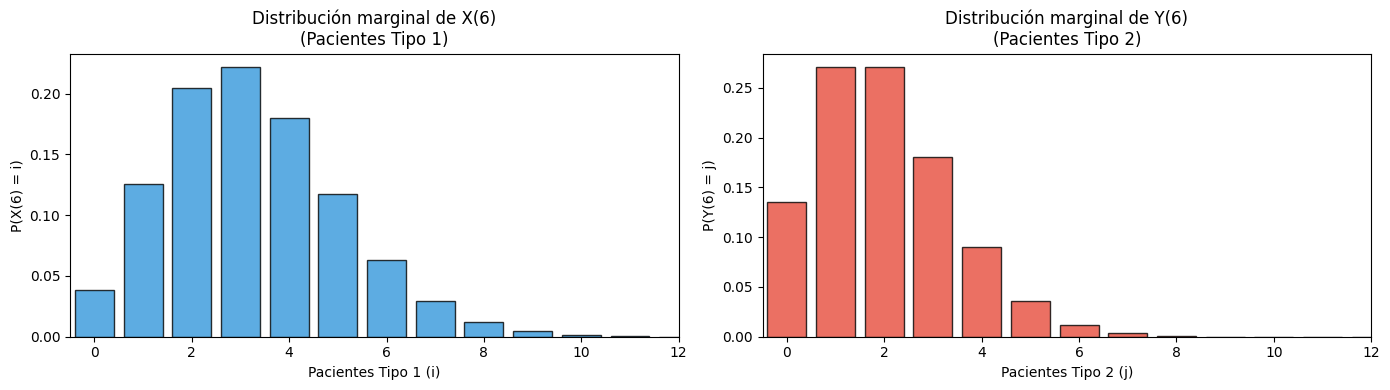

In [21]:
# histogramas de las distribuciones marginales
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Marginal de X (tipo 1)
axes[0].bar(range(B+1), marginal_X, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Pacientes Tipo 1 (i)')
axes[0].set_ylabel('P(X(6) = i)')
axes[0].set_title('Distribución marginal de X(6)\n(Pacientes Tipo 1)')
axes[0].set_xlim(-0.5, 12)

# Marginal de Y (tipo 2)
axes[1].bar(range(B-b+1), marginal_Y, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Pacientes Tipo 2 (j)')
axes[1].set_ylabel('P(Y(6) = j)')
axes[1].set_title('Distribución marginal de Y(6)\n(Pacientes Tipo 2)')
axes[1].set_xlim(-0.5, 12)

plt.tight_layout()
plt.show()

<h4 style="color: #ADD8E6;">5. Comparación con Simulación en SimPy</h4>

En las sesiones anteriores utilizamos **SimPy** para simular sistemas de colas. Dado que una Cadena de Markov en Tiempo Continuo (CMTC) se basa en eventos que ocurren en el tiempo (llegadas, salidas, transiciones), podemos usar el entorno de SimPy para simular el comportamiento dinámico de nuestro hospital.

Para esto, simularemos el hospital múltiples veces, parando el reloj de SimPy exactamente a las 6 horas, para revisar en qué estado se encuentra. Para esto se modelarán las llegadas como procesos de Poisson y los tiempos de servicio como exponenciales.


In [22]:
import simpy
import numpy as np

def simular_hospital_procesos(n_simulaciones, t_final, semilla=42):
    # Simula el hospital modelando llegadas y salidas de cada tipo de paciente.
    # Retorna un array con el estado (x1, x2) al final de cada réplica.
    rng = np.random.default_rng(semilla)
    resultados = []
    
    for _ in range(n_simulaciones):
        env = simpy.Environment()
        
        # Estado del sistema
        estado = {'tipo1': 0, 'tipo2': 0}
        
        # Proceso de llegadas Tipo 1
        def llegadas_tipo1(env, estado):
            while True:
                # Tiempo entre llegadas ~ Exp(λ₁)
                yield env.timeout(rng.exponential(1 / lambda_1))
                # Admitir si hay cama disponible (i < B)
                if estado['tipo1'] < B:
                    estado['tipo1'] += 1
                    # Calcular la salida de este paciente
                    env.process(servicio_tipo1(env, estado))
        
        # Proceso de llegadas Tipo 2
        def llegadas_tipo2(env, estado):
            while True:
                yield env.timeout(rng.exponential(1 / lambda_2))
                # Admitir solo si j < B - b
                if estado['tipo2'] < B - b:
                    estado['tipo2'] += 1
                    env.process(servicio_tipo2(env, estado))
        
        # Tiempo de servicio de un paciente Tipo 1
        def servicio_tipo1(env, estado):
            yield env.timeout(rng.exponential(1 / mu_1))
            estado['tipo1'] -= 1
        
        # Tiempo de servicio de un paciente Tipo 2
        def servicio_tipo2(env, estado):
            yield env.timeout(rng.exponential(1 / mu_2))
            estado['tipo2'] -= 1
        
        # Iniciar los procesos de llegada
        env.process(llegadas_tipo1(env, estado))
        env.process(llegadas_tipo2(env, estado))
        
        # Correr hasta t_final
        env.run(until=t_final)
        
        resultados.append((estado['tipo1'], estado['tipo2']))
    
    return resultados

# Ejecutar la simulación
n_sim = 50_000
resultados_sim = simular_hospital_procesos(n_sim, t_final=6.0, semilla=42)
print(f"Simulación completada con {n_sim} réplicas")


Simulación completada con 50000 réplicas


In [23]:
# Mapear los resultados a índices de estados con index(i, j)
estados_simulados = [index(i, j) for i, j in resultados_sim]

# Contar las ocurrencias de cada estado
conteos_estados = np.bincount(estados_simulados)

# Calcular el vector de probabilidades dividiendo por el total de simulaciones
probs_simuladas_6h = conteos_estados / n_sim

# Probabilidad de que el estado sea (1,3)
idx_1_3 = index(1,3)
prob_1_3_sim = probs_simuladas_6h[idx_1_3]
prob_1_3 = probs_transitorias_6h[idx_1_3]
print(f"P(X(6)=1, Y(6)=3):")
print(f"Resultado simulado = {prob_1_3_sim:.6f}")
print(f"Resultado de jmarkov = {prob_1_3:.6f}")

P(X(6)=1, Y(6)=3):
Resultado simulado = 0.023180
Resultado de jmarkov = 0.022737


Al igual que en casos anteriores, podemos observar cómo la simulación logra una excelente aproximación al resultado exacto resuelto mediante la matriz exponencial de la distribución transitoria en `jmarkov`. 

Por el teorema de la Ley de los números grandes, a medida que aumentemos el número de réplicas (`n_simulaciones`), nuestra probabilidad estimada convergerá de manera mucho más exacta a la probabilidad teórica calculada por la herramienta analítica.

<h4 style="color: #ADD8E6;">(Opcional) Simulación modelando saltos a partir de la matriz Q</h4>

También es posible usar la matriz $Q$ directamente para generar tiempos de permanencia y transiciones.

**Intuición**
1. Utilizamos la tasa de salida ($-q_{ii}$) de la diagonal de la matriz, y generamos números aleatorios exponenciales `rng.exponential`
2. Una vez transcurrido el tiempo, calculamos las probabilidades de salto de la cadena $p_{ij} = q_{ij} / -q_{ii}$ y hacemos la transición a un nuevo estado.

In [24]:
def simular_saltos_Q(Q_mat, estado_inicial, t_final, n_simulaciones, semilla=42):
    # Simula una CMTC general usando la matriz Q directamente.
    # Tiempo de permanencia ~ Exp(-q_ii), salto con prob q_ij/(-q_ii)
    rng = np.random.default_rng(semilla)
    n = Q_mat.shape[0]
    estados_finales = []
    
    for _ in range(n_simulaciones):
        estado = estado_inicial
        t = 0.0
        
        while True:
            tasa_salida = -Q_mat[estado, estado]
            
            if tasa_salida <= 0:
                break  # Estado absorbente
            
            # Tiempo de permanencia
            dt = rng.exponential(1 / tasa_salida)
            
            if t + dt >= t_final:
                break  # Se acabó el tiempo, nos quedamos en este estado
            t += dt
            
            # Probabilidades de salto
            probs = Q_mat[estado, :].copy()
            probs[estado] = 0.0
            probs = probs / tasa_salida
            
            # Nuevo estado
            estado = rng.choice(n, p=probs)
        
        estados_finales.append(estado)
    
    return estados_finales

# Ejecutar la simulación de saltos con la matriz Q
estados_finales_Q = simular_saltos_Q(Q_hospital, index(0,0), 6.0, n_sim, semilla=42)

# Comparar con jmarkov
prob_1_3_Q = sum(1 for s in estados_finales_Q if s == index(1,3)) / n_sim
print(f"P(X(6)=1, Y(6)=3):")
print(f"  jmarkov:        {prob_1_3:.6f}")
print(f"  Sim. procesos:  {prob_1_3_sim:.6f}")
print(f"  Sim. saltos Q:  {prob_1_3_Q:.6f}")


P(X(6)=1, Y(6)=3):
  jmarkov:        0.022737
  Sim. procesos:  0.023180
  Sim. saltos Q:  0.023500


**Preguntas de profundización**

- ¿Por qué si la semilla utilizada en los dos ejemplos de simulación fue la misma los resultados dieron distintos?
- A partir de los vectores simulados elabore un mapa de calor y compare con los resultados de `jmarkov`


<h4 style="color: #ADD8E6;">Próxima sesión</h4>

En la siguiente sesión profundizaremos en el análisis transitorio vs estado estable, mostraremos cómo la distribución converge al estado estable, y responderemos preguntas más complejas sobre el hospital (costos, tiempos de primera pasada, tiempos de ocupación).

Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co